In [2]:
%pip -q install duckdb huggingface_hub scikit-learn pandas matplotlib

In [3]:
import os, duckdb, pandas as pd
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
T = {
 'clients': f"read_parquet('{REL}/dim_clients.parquet')",
 'content': f"read_parquet('{REL}/dim_content.parquet')",
 'daily':   f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
 'sample':  f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
 'q90':     f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}


In [4]:
for name in ['daily', 'content', 'q90']:
    print(f'\n--- {name} ---')
    print(con.sql(f"DESCRIBE SELECT * FROM {T[name]}").df()[['column_name','column_type']].to_string(index=False))

print(con.sql(f"SELECT MIN(report_date) AS start_d, MAX(report_date) AS end_d, COUNT(DISTINCT client_hash_id) AS clients FROM {T['daily']}").df())


print(con.sql(f"SELECT * FROM {T['q90']} LIMIT 3").df().T)


--- daily ---
             column_name column_type
             report_date        DATE
          client_hash_id     VARCHAR
         content_hash_id     VARCHAR
          client_has_gsc     BOOLEAN
          client_has_ga4     BOOLEAN
      gsc_data_available     BOOLEAN
      ga4_data_available     BOOLEAN
         gsc_impressions      BIGINT
              gsc_clicks      BIGINT
        gsc_sum_position      BIGINT
        gsc_avg_position      DOUBLE
           ga4_pageviews      BIGINT
            ga4_sessions      BIGINT
               ga4_users      BIGINT
    ga4_engaged_sessions      BIGINT
ga4_total_engagement_sec      BIGINT
        sessions_organic      BIGINT
         sessions_direct      BIGINT
       sessions_referral      BIGINT
         sessions_social      BIGINT
           sessions_paid      BIGINT
             sessions_ai      BIGINT
              ai_chatgpt      BIGINT
           ai_perplexity      BIGINT
               ai_gemini      BIGINT
              ai_copilo

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     start_d      end_d  clients
0 2025-01-27 2026-06-30       70
                                                      0  \
client_hash_id                  client_08a6a72ff48e62c0   
content_hash_id                content_447894f2faf0d2bc   
query_hash_id                    query_58b1b001f839d699   
query_char_count                                     17   
query_token_count                                     3   
window_start                        2026-04-02 00:00:00   
window_end                          2026-06-30 00:00:00   
impressions_90d                                      11   
clicks_90d                                            0   
impressions_last30                                    0   
clicks_last30                                         0   
impressions_prev30                                   11   
clicks_prev30                                         0   
avg_position_90d                              10.818182   
avg_position_last30                              

In [ ]:
con.execute("SET memory_limit='8GB'")
con.execute("SET temp_directory='/content/duck_tmp'")

con.execute(f"""
COPY (
  SELECT client_hash_id, content_hash_id,
         date_trunc('week', report_date)::DATE AS wk,
         SUM(COALESCE(gsc_impressions,0)) AS imp,
         SUM(COALESCE(gsc_clicks,0))      AS clk,
         SUM(COALESCE(gsc_avg_position,0) * COALESCE(gsc_impressions,0)) AS pos_x_imp
  FROM {T['daily']}
  WHERE report_date < DATE '2026-06-29' AND gsc_data_available
  GROUP BY 1,2,3
) TO '/content/weekly.parquet' (FORMAT PARQUET)
""")

print(con.sql("SELECT COUNT(*) AS rows, MIN(wk) AS first_wk, MAX(wk) AS last_wk FROM read_parquet('/content/weekly.parquet')").df())



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
print(con.sql(f"""
  SELECT COUNT(*) AS rows, COUNT(DISTINCT (client_hash_id, content_hash_id)) AS unique_pages
  FROM {T['content']}
""").df())

In [ ]:
import pandas as pd

cut = pd.DataFrame({'cutoff': [(pd.Timestamp('2026-06-01') - pd.Timedelta(days=28*k)).date() for k in range(16)]})
con.register('cutoffs_df', cut)
con.execute("CREATE OR REPLACE TABLE cutoffs AS SELECT CAST(cutoff AS DATE) AS cutoff FROM cutoffs_df")

panel = con.sql(f"""
WITH w AS (
  SELECT c.cutoff, x.client_hash_id, x.content_hash_id, x.wk, x.imp, x.clk, x.pos_x_imp
  FROM read_parquet('/content/weekly.parquet') x
  JOIN cutoffs c
    ON x.wk >= c.cutoff - INTERVAL 91 DAY AND x.wk < c.cutoff + INTERVAL 28 DAY
),
agg AS (
  SELECT cutoff, client_hash_id, content_hash_id,
    COALESCE(SUM(imp) FILTER (WHERE wk >= cutoff - INTERVAL 28 DAY AND wk < cutoff),0) AS imp_f4,
    COALESCE(SUM(imp) FILTER (WHERE wk >= cutoff - INTERVAL 56 DAY AND wk < cutoff - INTERVAL 28 DAY),0) AS imp_p4,
    COALESCE(SUM(imp) FILTER (WHERE wk >= cutoff - INTERVAL 91 DAY AND wk < cutoff - INTERVAL 56 DAY),0) AS imp_older5,
    COALESCE(SUM(clk) FILTER (WHERE wk >= cutoff - INTERVAL 28 DAY AND wk < cutoff),0) AS clk_f4,
    COALESCE(SUM(clk) FILTER (WHERE wk >= cutoff - INTERVAL 56 DAY AND wk < cutoff - INTERVAL 28 DAY),0) AS clk_p4,
    SUM(pos_x_imp) FILTER (WHERE wk >= cutoff - INTERVAL 28 DAY AND wk < cutoff)
      / NULLIF(SUM(imp) FILTER (WHERE wk >= cutoff - INTERVAL 28 DAY AND wk < cutoff),0) AS pos_f4,
    SUM(pos_x_imp) FILTER (WHERE wk >= cutoff - INTERVAL 56 DAY AND wk < cutoff - INTERVAL 28 DAY)
      / NULLIF(SUM(imp) FILTER (WHERE wk >= cutoff - INTERVAL 56 DAY AND wk < cutoff - INTERVAL 28 DAY),0) AS pos_p4,
    COUNT(*) FILTER (WHERE wk >= cutoff - INTERVAL 56 DAY AND wk < cutoff AND imp > 0) AS weeks_active_8,
    STDDEV_SAMP(imp) FILTER (WHERE wk >= cutoff - INTERVAL 56 DAY AND wk < cutoff) AS imp_std8,
    COALESCE(SUM(imp) FILTER (WHERE wk >= cutoff AND wk < cutoff + INTERVAL 28 DAY),0) AS imp_l4,
    COALESCE(SUM(clk) FILTER (WHERE wk >= cutoff AND wk < cutoff + INTERVAL 28 DAY),0) AS clk_l4
  FROM w GROUP BY cutoff, client_hash_id, content_hash_id
),
withclient AS (
  SELECT *, SUM(imp_l4) OVER (PARTITION BY cutoff, client_hash_id) AS client_imp_l4 FROM agg
)
SELECT a.*,
  d.content_type, d.main_intent, d.competition_level,
  d.search_volume, d.competition, d.cpc, d.backlinks, d.word_count,
  d.keyword_token_count, d.url_char_count, d.category_count,
  DATE_DIFF('day', d.content_created_date, a.cutoff) AS age_days,
  CASE WHEN d.content_updated_date  < a.cutoff THEN DATE_DIFF('day', d.content_updated_date,  a.cutoff) END AS days_since_update,
  CASE WHEN d.last_optimized_date   < a.cutoff THEN DATE_DIFF('day', d.last_optimized_date,   a.cutoff) END AS days_since_opt
FROM withclient a
LEFT JOIN {T['content']} d USING (client_hash_id, content_hash_id)
WHERE a.imp_f4 >= 250 AND a.client_imp_l4 > 0
""").df()

panel['y'] = (panel.imp_l4 < 0.8 * panel.imp_f4).astype(int)
panel.to_parquet('/content/panel.parquet')

print(panel.shape)
print(panel.groupby('cutoff').agg(rows=('y','size'), decline_rate=('y','mean'), clients=('client_hash_id','nunique')))

In [ ]:
panel['cutoff'] = pd.to_datetime(panel['cutoff'])
panel['ratio'] = panel.imp_l4 / panel.imp_f4

# 1. Total weekly impressions and active clients over time (last 16 weeks)
wk = con.sql("""
  SELECT wk, SUM(imp) AS imp, COUNT(DISTINCT client_hash_id) AS clients
  FROM read_parquet('/content/weekly.parquet')
  GROUP BY wk ORDER BY wk
""").df()
print(wk.tail(16).to_string(index=False))

# 2. Decomposing the last three cutoffs
late = panel[panel.cutoff >= '2026-04-06'].copy()
print('\nshare of pages with ZERO label-window impressions:',
      round((late.imp_l4 == 0).mean(), 3))
print('decline rate excluding zero-label pages:',
      round(late.loc[late.imp_l4 > 0, 'y'].mean(), 3))

# 3. Client concentration and per-client decline rate at the latest cutoff
lc = panel[panel.cutoff == '2026-06-01']
by_client = (lc.groupby('client_hash_id')
               .agg(rows=('y','size'), decline_rate=('y','mean'),
                    zero_label=('imp_l4', lambda s: (s == 0).mean()),
                    median_ratio=('ratio','median'))
               .sort_values('rows', ascending=False))
by_client['row_share'] = by_client.rows / by_client.rows.sum()
print('\n', by_client.head(10).round(3).to_string())
print('\ndecline rate excluding top-3 clients:',
      round(lc[~lc.client_hash_id.isin(by_client.index[:3])].y.mean(), 3))

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

# --- relative label ---
panel['ratio'] = panel.imp_l4 / panel.imp_f4
g = panel.groupby(['cutoff', 'client_hash_id'])
panel['cc_n'] = g['ratio'].transform('size')
panel['cc_med_ratio'] = g['ratio'].transform('median')

df = panel[panel.cc_n >= 30].copy()          # need enough peers for a stable client median
df['y_rel'] = (df.ratio < 0.8 * df.cc_med_ratio).astype(int)

print('rows kept:', len(df), 'of', len(panel), '| clients:', df.client_hash_id.nunique())
print(df.groupby('cutoff').agg(rows=('y_rel','size'),
                               rel_rate=('y_rel','mean'),
                               abs_rate=('y','mean'),
                               clients=('client_hash_id','nunique')).round(3))

# --- baselines (directions fixed in advance) ---
# B1: "recent decline continues"  -> lower recent/prior ratio = higher risk
df['b_momentum'] = -np.log((df.imp_f4 + 1) / (df.imp_p4 + 1))
# B2: "high-position pages fall back less" -> worse (higher) position = higher risk
df['b_position'] = df.pos_f4.fillna(df.pos_f4.median())
# B3: "page already volatile" -> higher variability relative to volume
df['b_volatility'] = (df.imp_std8 / (df.imp_f4 / 4 + 1)).fillna(0)

def lift_top10(d, score, target):
    k = max(1, int(0.10 * len(d)))
    top = d.sort_values(score, ascending=False).head(k)
    return top[target].mean() / d[target].mean()

test = df[df.cutoff >= '2026-03-09']
rows = []
for s in ['b_momentum', 'b_position', 'b_volatility']:
    rows.append({
        'baseline': s,
        'AUC_test': roc_auc_score(test.y_rel, test[s]),
        'PR_AUC_test': average_precision_score(test.y_rel, test[s]),
        'lift@top10%': lift_top10(test, s, 'y_rel'),
    })
print('\nprior rate on test:', round(test.y_rel.mean(), 3))
print(pd.DataFrame(rows).round(3).to_string(index=False))

df.to_parquet('/content/panel_rel.parquet')

In [ ]:
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance

df = pd.read_parquet('/content/panel_rel.parquet')
df['cutoff'] = pd.to_datetime(df['cutoff'])

# ---------- features (pre-cutoff information only) ----------
older_rate = df.imp_older5 / 5 * 4
base = (df.imp_p4 + older_rate) / 2
df['log_imp_f4']  = np.log1p(df.imp_f4)
df['log_mom']     = np.log((df.imp_f4 + 1) / (df.imp_p4 + 1))
df['spike']       = np.log((df.imp_f4 + 1) / (base + 1))
df['ctr_f4']      = df.clk_f4 / df.imp_f4
df['ctr_p4']      = np.where(df.imp_p4 > 0, df.clk_p4 / df.imp_p4.replace(0, np.nan), np.nan)
df['pos_delta']   = df.pos_f4 - df.pos_p4
df['cv8']         = df.imp_std8 / (df.imp_f4 / 4 + 1)

cc = df.groupby(['cutoff', 'client_hash_id'])
df['client_mom'] = np.log((cc.imp_f4.transform('sum') + 1) / (cc.imp_p4.transform('sum') + 1))
df['rel_mom']    = df.log_mom - df.client_mom

cats = ['content_type', 'main_intent', 'competition_level']
for c in cats:
    df[c] = df[c].astype('category')

num = ['log_imp_f4','log_mom','spike','ctr_f4','ctr_p4','pos_f4','pos_p4','pos_delta',
       'weeks_active_8','cv8','imp_std8','client_mom','rel_mom',
       'search_volume','competition','cpc','backlinks','word_count','keyword_token_count',
       'url_char_count','category_count','age_days','days_since_update','days_since_opt']
FEATS = num + cats
TARGET = 'y_rel'

def make_model():
    return HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.05, max_leaf_nodes=31, min_samples_leaf=200,
        l2_regularization=1.0, categorical_features='from_dtype', random_state=42)

def lift_top10(y, s):
    k = max(1, int(0.10 * len(y)))
    idx = np.argsort(-s)[:k]
    return y[idx].mean() / y.mean()

# ---------- time-aware split ----------
train = df[df.cutoff <= '2026-01-12']
test  = df[df.cutoff >= '2026-03-09']
print(f'train {len(train):,} rows | test {len(test):,} rows')

m = make_model().fit(train[FEATS], train[TARGET])
p = m.predict_proba(test[FEATS])[:, 1]
y = test[TARGET].values

print('''
=== TIME-AWARE TEST ===''')
print('prior rate:', round(y.mean(), 3))
print('MODEL      AUC %.3f | PR-AUC %.3f | lift@10%% %.2f' %
      (roc_auc_score(y, p), average_precision_score(y, p), lift_top10(y, p)))
bv = test.cv8.fillna(0).values # Fill NaN values with 0
print('BASELINE   AUC %.3f | PR-AUC %.3f | lift@10%% %.2f  (volatility)' %
      (roc_auc_score(y, bv), average_precision_score(y, bv), lift_top10(y, bv)))

print('''
per-cutoff AUC (model vs volatility baseline):''')
for c, g in test.assign(p=p).groupby('cutoff'):
    # Also fill NaN for cv8 in the grouped data
    print(c.date(), round(roc_auc_score(g[TARGET], g.p), 3), '|',
          round(roc_auc_score(g[TARGET], g.cv8.fillna(0)), 3))

# ---------- client-grouped CV (does it generalize to unseen clients?) ----------
print('''
=== GROUPED-BY-CLIENT 5-FOLD CV ===''')
aucs, base_aucs = [], []
for k, (tr, te) in enumerate(GroupKFold(5).split(df, groups=df.client_hash_id)):
    mk = make_model().fit(df.iloc[tr][FEATS], df.iloc[tr][TARGET])
    pk = mk.predict_proba(df.iloc[te][FEATS])[:, 1]
    yk = df.iloc[te][TARGET].values
    # Fill NaN values with 0 for the baseline in each fold
    aucs.append(roc_auc_score(yk, pk))
    base_aucs.append(roc_auc_score(yk, df.iloc[te].cv8.fillna(0).values))
    print(f'fold {k}: model {aucs[-1]:.3f} | volatility baseline {base_aucs[-1]:.3f}')
print(f'mean AUC: model {np.mean(aucs):.3f} | baseline {np.mean(base_aucs):.3f}')

# ---------- what drives it? ----------
samp = test.sample(min(30000, len(test)), random_state=1)
pi = permutation_importance(m, samp[FEATS], samp[TARGET], scoring='roc_auc',
                            n_repeats=3, random_state=1)
imp = pd.Series(pi.importances_mean, index=FEATS).sort_values(ascending=False)
print('\n=== permutation importance (drop in test AUC) ===')
print(imp.head(12).round(4).to_string())

In [11]:
from sklearn.model_selection import GroupKFold

test_cuts = sorted(df[df.cutoff >= '2026-03-09'].cutoff.unique())

# fixed client -> fold mapping (balanced by rows)
cl = df.client_hash_id.values
fold_of = {}
for k, (_, te) in enumerate(GroupKFold(5).split(df, groups=cl)):
    for c in np.unique(cl[te]):
        fold_of[c] = k
df['fold'] = df.client_hash_id.map(fold_of)

parts = []
for tc in test_cuts:
    tc = pd.Timestamp(tc)
    tr_all = df[df.cutoff <= tc - pd.Timedelta(days=28)]
    te_all = df[df.cutoff == tc]

    # (a) walk-forward, all clients
    ma = make_model().fit(tr_all[FEATS], tr_all[TARGET])
    out = te_all[['cutoff', 'client_hash_id', TARGET, 'cv8']].copy()
    out['p_time'] = ma.predict_proba(te_all[FEATS])[:, 1]

    # (b) walk-forward + unseen clients
    out['p_strict'] = np.nan
    for k in range(5):
        trk = tr_all[tr_all.fold != k]
        tek = te_all[te_all.fold == k]
        if len(tek) == 0:
            continue
        mk = make_model().fit(trk[FEATS], trk[TARGET])
        out.loc[tek.index, 'p_strict'] = mk.predict_proba(tek[FEATS])[:, 1]

    parts.append(out)
    print('done', tc.date(), '| train rows:', f'{len(tr_all):,}')

res = pd.concat(parts)
y = res[TARGET].values

def summarize(name, s):
    # Fill NaN values with 0 before calculating metrics
    s = np.nan_to_num(s, nan=0.0)
    print(f'{name:38} AUC {roc_auc_score(y, s):.3f} | PR-AUC {average_precision_score(y, s):.3f} | lift@10% {lift_top10(y, s):.2f}')

print('\nprior rate:', round(y.mean(), 3))
summarize('baseline (volatility)', res.cv8.values)
summarize('model, walk-forward (seen clients)', res.p_time.values)
summarize('model, walk-forward + UNSEEN clients', res.p_strict.values)

print('\nper-cutoff AUC: baseline | walk-forward | strict')
for c, g in res.groupby('cutoff'):
    # Also fill NaN for cv8 in the grouped data before calculating metrics
    print(c.date(), round(roc_auc_score(g[TARGET], g.cv8.fillna(0)), 3), '|',
          round(roc_auc_score(g[TARGET], g.p_time), 3), '|',
          round(roc_auc_score(g[TARGET], g.p_strict), 3))

# ---- client-level bootstrap: model(strict) AUC minus baseline AUC ----
rng = np.random.default_rng(0)
idx_by_client = res.reset_index(drop=True).groupby('client_hash_id').indices
clients = np.array(list(idx_by_client))
# Ensure arr_b (baseline) is filled with 0 for NaN values
arr_y, arr_b, arr_s = y, res.cv8.fillna(0).values, res.p_strict.values
diffs = []
for _ in range(200):
    pick = rng.choice(clients, size=len(clients), replace=True)
    ii = np.concatenate([idx_by_client[c] for c in pick])
    if arr_y[ii].min() == arr_y[ii].max():
        continue
    diffs.append(roc_auc_score(arr_y[ii], arr_s[ii]) - roc_auc_score(arr_y[ii], arr_b[ii]))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f'\nAUC gain (strict model - baseline): {np.mean(diffs):+.3f}  95% client-bootstrap CI [{lo:+.3f}, {hi:+.3f}]')

res.to_parquet('/content/eval_predictions.parquet')

done 2026-03-09 | train rows: 228,235
done 2026-04-06 | train rows: 292,675
done 2026-05-04 | train rows: 370,407
done 2026-06-01 | train rows: 449,341

prior rate: 0.339
baseline (volatility)                  AUC 0.609 | PR-AUC 0.409 | lift@10% 1.26
model, walk-forward (seen clients)     AUC 0.641 | PR-AUC 0.473 | lift@10% 1.68
model, walk-forward + UNSEEN clients   AUC 0.631 | PR-AUC 0.462 | lift@10% 1.61

per-cutoff AUC: baseline | walk-forward | strict
2026-03-09 0.584 | 0.61 | 0.591
2026-04-06 0.602 | 0.647 | 0.632
2026-05-04 0.676 | 0.668 | 0.675
2026-06-01 0.563 | 0.632 | 0.621

AUC gain (strict model - baseline): +0.024  95% client-bootstrap CI [+0.003, +0.055]


In [12]:
T_SCORE = pd.Timestamp('2026-06-29')
cut = "DATE '2026-06-29'"

sp = con.sql(f"""
WITH w AS (
  SELECT * FROM read_parquet('/content/weekly.parquet')
  WHERE wk >= {cut} - INTERVAL 91 DAY AND wk < {cut}
),
agg AS (
  SELECT client_hash_id, content_hash_id,
    COALESCE(SUM(imp) FILTER (WHERE wk >= {cut} - INTERVAL 28 DAY),0) AS imp_f4,
    COALESCE(SUM(imp) FILTER (WHERE wk >= {cut} - INTERVAL 56 DAY AND wk < {cut} - INTERVAL 28 DAY),0) AS imp_p4,
    COALESCE(SUM(imp) FILTER (WHERE wk < {cut} - INTERVAL 56 DAY),0) AS imp_older5,
    COALESCE(SUM(clk) FILTER (WHERE wk >= {cut} - INTERVAL 28 DAY),0) AS clk_f4,
    COALESCE(SUM(clk) FILTER (WHERE wk >= {cut} - INTERVAL 56 DAY AND wk < {cut} - INTERVAL 28 DAY),0) AS clk_p4,
    SUM(pos_x_imp) FILTER (WHERE wk >= {cut} - INTERVAL 28 DAY)
      / NULLIF(SUM(imp) FILTER (WHERE wk >= {cut} - INTERVAL 28 DAY),0) AS pos_f4,
    SUM(pos_x_imp) FILTER (WHERE wk >= {cut} - INTERVAL 56 DAY AND wk < {cut} - INTERVAL 28 DAY)
      / NULLIF(SUM(imp) FILTER (WHERE wk >= {cut} - INTERVAL 56 DAY AND wk < {cut} - INTERVAL 28 DAY),0) AS pos_p4,
    COUNT(*) FILTER (WHERE wk >= {cut} - INTERVAL 56 DAY AND imp > 0) AS weeks_active_8,
    STDDEV_SAMP(imp) FILTER (WHERE wk >= {cut} - INTERVAL 56 DAY) AS imp_std8
  FROM w GROUP BY 1,2
)
SELECT a.*, {cut} AS cutoff,
  d.content_type, d.main_intent, d.competition_level,
  d.search_volume, d.competition, d.cpc, d.backlinks, d.word_count,
  d.keyword_token_count, d.url_char_count, d.category_count,
  DATE_DIFF('day', d.content_created_date, {cut}) AS age_days,
  CASE WHEN d.content_updated_date < {cut} THEN DATE_DIFF('day', d.content_updated_date, {cut}) END AS days_since_update,
  CASE WHEN d.last_optimized_date  < {cut} THEN DATE_DIFF('day', d.last_optimized_date,  {cut}) END AS days_since_opt
FROM agg a
LEFT JOIN {T['content']} d USING (client_hash_id, content_hash_id)
WHERE a.imp_f4 >= 250
""").df()

sp['cutoff'] = T_SCORE
sp['ratio_dummy'] = 1.0
sp['cc_n'] = sp.groupby('client_hash_id').content_hash_id.transform('size')
sp = sp[sp.cc_n >= 30].copy()        # same eligibility rule as training

# ---- identical feature engineering to training ----
older_rate = sp.imp_older5 / 5 * 4
base = (sp.imp_p4 + older_rate) / 2
sp['log_imp_f4'] = np.log1p(sp.imp_f4)
sp['log_mom']    = np.log((sp.imp_f4 + 1) / (sp.imp_p4 + 1))
sp['spike']      = np.log((sp.imp_f4 + 1) / (base + 1))
sp['ctr_f4']     = sp.clk_f4 / sp.imp_f4
sp['ctr_p4']     = np.where(sp.imp_p4 > 0, sp.clk_p4 / sp.imp_p4.replace(0, np.nan), np.nan)
sp['pos_delta']  = sp.pos_f4 - sp.pos_p4
sp['cv8']        = sp.imp_std8 / (sp.imp_f4 / 4 + 1)
cc_ = sp.groupby('client_hash_id')
sp['client_mom'] = np.log((cc_.imp_f4.transform('sum') + 1) / (cc_.imp_p4.transform('sum') + 1))
sp['rel_mom']    = sp.log_mom - sp.client_mom
for c in cats:
    sp[c] = pd.Categorical(sp[c], categories=df[c].cat.categories)

# ---- final model on ALL labelled cutoffs ----
final = make_model().fit(df[FEATS], df[TARGET])
sp['risk'] = final.predict_proba(sp[FEATS])[:, 1]

print('pages scored:', f'{len(sp):,}', '| clients:', sp.client_hash_id.nunique())
print(sp.risk.describe().round(3))

pages scored: 71,497 | clients: 34
count    71497.000
mean         0.289
std          0.129
min          0.015
25%          0.197
50%          0.273
75%          0.367
max          0.912
Name: risk, dtype: float64


In [19]:
qs = con.sql(f"""
  SELECT client_hash_id, content_hash_id,
         ANY_VALUE(content_visible_query_count)   AS visible_queries,
         ANY_VALUE(rare_impressions_share)        AS rare_share,
         ANY_VALUE(anonymized_impressions_share)  AS anon_share,
         MAX(impressions_90d) AS top_q_imp, SUM(impressions_90d) AS kept_imp
  FROM {T['q90']} GROUP BY 1, 2
""").df()
qs['top_q_share'] = qs.top_q_imp / qs.kept_imp
sp = sp.merge(qs.drop(columns=['top_q_imp','kept_imp']), on=['client_hash_id','content_hash_id'], how='left')

# CTR relative to same-client pages at similar position
sp['pos_band'] = pd.cut(sp.pos_f4, [0, 3, 5, 10, 20, 1000])
sp['ctr_band_med'] = sp.groupby(['client_hash_id', 'pos_band'], observed=True).ctr_f4.transform('median')
sp['wc_q25'] = sp.groupby('client_hash_id').word_count.transform(lambda s: s.quantile(0.25))

# Ensure 'visible_queries' and 'top_q_share' columns exist in sp
# This handles cases where the merge might not add them (e.g., if qs is empty or no matches)
if 'visible_queries' not in sp.columns:
    sp['visible_queries'] = np.nan
if 'top_q_share' not in sp.columns:
    sp['top_q_share'] = np.nan

RULES = {
 'DECLINING':        sp.imp_f4 < 0.8 * sp.imp_p4,                       # recent 4 wks < 80% of prior 4
 'POSITION_SLIP':    sp.pos_delta >= 1.5,                               # avg position worsened 1.5+ places
 'SPIKE_REVERSION':  sp.spike > np.log(1.5),                            # recent volume 50%+ above own baseline
 'LOW_CTR':          (sp.ctr_f4 < 0.5 * sp.ctr_band_med) & (sp.ctr_band_med > 0) & (sp.imp_f4 >= 500),
 'NARROW_QUERY_BASE':(sp.visible_queries.fillna(0) <= 3) | (sp.top_q_share.fillna(0) >= 0.6),
 'STALE_CONTENT':    (sp.days_since_update > 365) | (sp.days_since_update.isna() & (sp.age_days > 365)),
 'THIN_CONTENT':     sp.word_count < sp.wc_q25,
 'STRIKING_DISTANCE':(sp.pos_f4 >= 8) & (sp.pos_f4 <= 20) & (sp.imp_f4 >= 1000),
}
for k, v in RULES.items():
    sp[k] = v.fillna(False)
codes = list(RULES)
sp['reason_codes'] = sp[codes].apply(lambda r: ', '.join(c for c in codes if r[c]), axis=1)

# risk percentile within client, so small clients get their own priorities
sp['risk_pct_in_client'] = sp.groupby('client_hash_id').risk.rank(pct=True)
sp['impressions_at_stake'] = sp.risk * sp.imp_f4

def action(r):
    if r.risk_pct_in_client >= 0.90 and (r.DECLINING or r.POSITION_SLIP or r.SPIKE_REVERSION):
        return 'REFRESH_REVIEW'
    if r.LOW_CTR:
        return 'METADATA_REVIEW'
    if r.STRIKING_DISTANCE and r.risk_pct_in_client < 0.70:
        return 'IMPROVE_FOR_GROWTH'
    if r.risk_pct_in_client >= 0.70:
        return 'MONITOR_CLOSELY'
    return 'MONITOR'
sp['action'] = sp.apply(action, axis=1)

print(sp.action.value_counts())
print('\nreason-code prevalence:')
print(sp[codes].mean().round(3).sort_values(ascending=False))
print('\nmean model risk by action:')
print(sp.groupby('action').risk.mean().round(3))


action
MONITOR               38928
MONITOR_CLOSELY       10860
METADATA_REVIEW        8584
IMPROVE_FOR_GROWTH     6880
REFRESH_REVIEW         6245
Name: count, dtype: int64

reason-code prevalence:
DECLINING            0.464
SPIKE_REVERSION      0.277
THIN_CONTENT         0.217
POSITION_SLIP        0.202
NARROW_QUERY_BASE    0.192
STRIKING_DISTANCE    0.163
LOW_CTR               0.16
STALE_CONTENT        0.019
dtype: Float64

mean model risk by action:
action
IMPROVE_FOR_GROWTH    0.226
METADATA_REVIEW       0.331
MONITOR               0.223
MONITOR_CLOSELY       0.393
REFRESH_REVIEW        0.535
Name: risk, dtype: float64


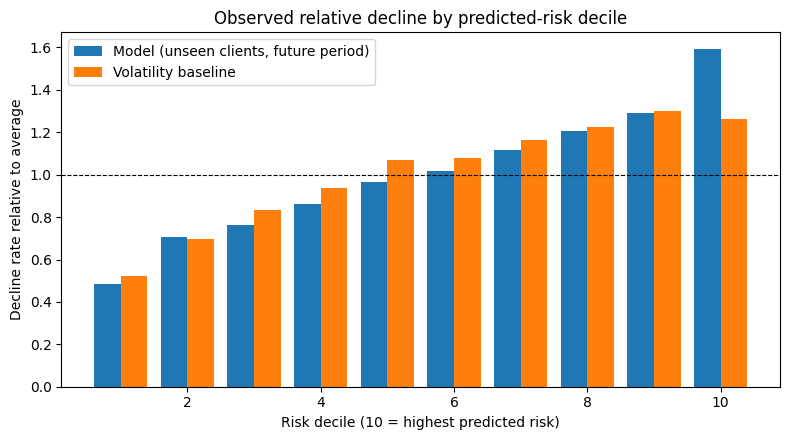

    model_lift  baseline_lift
1         0.48           0.52
2         0.70           0.70
3         0.76           0.83
4         0.86           0.94
5         0.97           1.07
6         1.02           1.08
7         1.12           1.17
8         1.21           1.23
9         1.29           1.30
10        1.59           1.26
                    pages  mean_risk  median_impressions
action                                                  
IMPROVE_FOR_GROWTH   6880      0.226              1876.5
METADATA_REVIEW      8584      0.331              1583.0
MONITOR             38928      0.223               726.0
MONITOR_CLOSELY     10860      0.393               520.0
REFRESH_REVIEW       6245      0.535               790.0
 rank  risk   imp_f4  impressions_at_stake          action                                                                        reason_codes
    1 0.455 585499.0              266186.0  REFRESH_REVIEW                                                                     S

In [17]:
import matplotlib.pyplot as plt

res = pd.read_parquet('/content/eval_predictions.parquet')
res['decile'] = res.groupby('cutoff').p_strict.transform(lambda s: pd.qcut(s.rank(method='first'), 10, labels=False)) + 1
res['dec_base'] = res.groupby('cutoff').cv8.transform(lambda s: pd.qcut(s.rank(method='first'), 10, labels=False)) + 1
prior = res.y_rel.mean()
m_rate = res.groupby('decile').y_rel.mean() / prior
b_rate = res.groupby('dec_base').y_rel.mean() / prior

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(1, 11)
ax.bar(x - 0.2, m_rate.values, 0.4, label='Model (unseen clients, future period)')
ax.bar(x + 0.2, b_rate.values, 0.4, label='Volatility baseline')
ax.axhline(1, color='k', lw=0.8, ls='--')
ax.set_xlabel('Risk decile (10 = highest predicted risk)')
ax.set_ylabel('Decline rate relative to average')
ax.set_title('Observed relative decline by predicted-risk decile')
ax.legend(); plt.tight_layout()
plt.savefig('/content/fig_decile_lift.png', dpi=160)
plt.show()
print(pd.DataFrame({'model_lift': m_rate, 'baseline_lift': b_rate}).round(2))

# ---- full ranked file (PRIVATE: do not commit) ----
cols = ['client_hash_id','content_hash_id','risk','imp_f4','impressions_at_stake','action','reason_codes']
ranked = sp.sort_values('impressions_at_stake', ascending=False)[cols]
ranked.to_parquet('/content/ranked_actions_PRIVATE.parquet')

# ---- public-safe summary: aggregates + anonymised example rows ----
pub = sp.groupby('action').agg(pages=('risk','size'), mean_risk=('risk','mean'),
                               median_impressions=('imp_f4','median')).round(3)
pub.to_csv('/content/public_action_summary.csv')
ex = ranked.head(15).copy()
ex.insert(0, 'rank', range(1, 16))
ex = ex.drop(columns=['client_hash_id','content_hash_id'])
ex['risk'] = ex.risk.round(3); ex['impressions_at_stake'] = ex.impressions_at_stake.round(0)
ex.to_csv('/content/public_example_rows.csv', index=False)
print(pub); print(ex.head(10).to_string(index=False))

In [22]:
# ---------- 1. Do the reason codes actually mark higher relative decline? ----------
h = df.copy()
h['pos_band'] = pd.cut(h.pos_f4, [0, 3, 5, 10, 20, 1000])
h['ctr_band_med'] = h.groupby(['cutoff','client_hash_id','pos_band'], observed=True).ctr_f4.transform('median')
h['wc_q25'] = h.groupby(['cutoff','client_hash_id']).word_count.transform(lambda s: s.quantile(0.25))

H_RULES = {
 'DECLINING':         h.imp_f4 < 0.8 * h.imp_p4,
 'POSITION_SLIP':     h.pos_delta >= 1.5,
 'SPIKE_REVERSION':   h.spike > np.log(1.5),
 'LOW_CTR':           (h.ctr_f4 < 0.5 * h.ctr_band_med) & (h.ctr_band_med > 0) & (h.imp_f4 >= 500),
 'STALE_CONTENT':     (h.days_since_update > 365) | (h.days_since_update.isna() & (h.age_days > 365)),
 'THIN_CONTENT':      h.word_count.fillna(0) < h.wc_q25.fillna(0),
 'STRIKING_DISTANCE': (h.pos_f4 >= 8) & (h.pos_f4 <= 20) & (h.imp_f4 >= 1000),
}
prior = h.y_rel.mean()
rows = []
for k, v in H_RULES.items():
    v = v.fillna(False)
    per_cut = h[v].groupby('cutoff').y_rel.mean() / h.groupby('cutoff').y_rel.mean().reindex(h[v].groupby('cutoff').size().index)
    rows.append({'code': k, 'share_of_pages': v.mean(),
                 'decline_rate': h.loc[v, 'y_rel'].mean(),
                 'lift_vs_prior': h.loc[v, 'y_rel'].mean() / prior,
                 'cutoffs_with_lift>1': f'{(per_cut > 1).sum()}/{len(per_cut)}'})
print('prior relative-decline rate:', round(prior, 3))
print(pd.DataFrame(rows).round(3).to_string(index=False))

# ---------- 2. Revised action logic ----------
def action2(r):
    hot = r.risk_pct_in_client >= 0.90
    if hot and (r.DECLINING or r.POSITION_SLIP):
        return 'REFRESH_REVIEW'
    if hot and r.SPIKE_REVERSION:
        return 'WATCH_SPIKE_REVERSION'      # expected to normalise; not a refresh case
    if r.LOW_CTR:
        return 'METADATA_REVIEW'
    if r.STRIKING_DISTANCE and r.risk_pct_in_client < 0.70:
        return 'IMPROVE_FOR_GROWTH'
    if r.risk_pct_in_client >= 0.70:
        return 'MONITOR_CLOSELY'
    return 'MONITOR'
sp['action'] = sp.apply(action2, axis=1)
print('\n', sp.action.value_counts())

# ---------- 3. Public-safe outputs (rounded, no IDs) ----------
def sig2(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    nz = x > 0
    if np.any(nz):
        decimals_arr = (-np.floor(np.log10(x[nz])).astype(int) + 1)
        # Apply np.round element-wise using a list comprehension to avoid internal numpy errors
        out[nz] = np.array([np.round(val, dec) for val, dec in zip(x[nz], decimals_arr)])
    return out

pub = sp.groupby('action').agg(pages=('risk','size'), mean_risk=('risk','mean')).round(3)
pub.to_csv('/content/public_action_summary.csv')

ranked = sp.sort_values('impressions_at_stake', ascending=False)
ranked[['client_hash_id','content_hash_id','risk','imp_f4','impressions_at_stake',
        'action','reason_codes']].to_parquet('/content/ranked_actions_PRIVATE.parquet')

# examples: highest-risk page per action type, rounded, no IDs
ex = (ranked.sort_values('risk', ascending=False).groupby('action').head(3)
            .sort_values(['action','risk'], ascending=[True, False]))
ex = pd.DataFrame({'action': ex.action.values,
                   'risk': ex.risk.round(2).values,
                   'recent_impressions_approx': sig2(ex.imp_f4.values),
                   'reason_codes': ex.reason_codes.values})
ex.to_csv('/content/public_example_rows.csv', index=False)
print(ex.to_string(index=False))


/tmp/ipykernel_1024/3401827273.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  'THIN_CONTENT':      h.word_count.fillna(0) < h.wc_q25.fillna(0),


prior relative-decline rate: 0.321
             code  share_of_pages  decline_rate  lift_vs_prior cutoffs_with_lift>1
        DECLINING           0.206         0.378          1.179               15/16
    POSITION_SLIP           0.311         0.343          1.068               10/16
  SPIKE_REVERSION           0.521         0.320          0.997               10/16
          LOW_CTR           0.182         0.419          1.304               14/16
    STALE_CONTENT           0.073         0.275          0.856                 1/7
     THIN_CONTENT           0.452         0.338          1.052               15/16
STRIKING_DISTANCE           0.124         0.303          0.943                5/16

 action
MONITOR                  38928
MONITOR_CLOSELY          10860
METADATA_REVIEW           8584
IMPROVE_FOR_GROWTH        6880
REFRESH_REVIEW            4021
WATCH_SPIKE_REVERSION     2224
Name: count, dtype: int64


TypeError: only integer scalar arrays can be converted to a scalar index

In [23]:
# ---- rename action, drop STALE_CONTENT from reason codes ----
sp['action'] = sp['action'].replace({'WATCH_SPIKE_REVERSION': 'WATCH_RECENT_SPIKE'})
codes_public = ['DECLINING', 'POSITION_SLIP', 'SPIKE_REVERSION', 'LOW_CTR',
                'NARROW_QUERY_BASE', 'THIN_CONTENT', 'STRIKING_DISTANCE']
sp['reason_codes'] = sp[codes_public].apply(
    lambda r: ', '.join(c for c in codes_public if r[c]), axis=1)

# ---- fixed rounding helper: 2 significant figures ----
def sig2(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    nz = x > 0
    mag = 10 ** (np.floor(np.log10(x[nz])) - 1)
    out[nz] = np.round(x[nz] / mag) * mag
    return out

# ---- private ranked file (do NOT commit) ----
ranked = sp.sort_values('impressions_at_stake', ascending=False)
ranked[['client_hash_id','content_hash_id','risk','imp_f4','impressions_at_stake',
        'action','reason_codes']].to_parquet('/content/ranked_actions_PRIVATE.parquet')

# ---- public summary: aggregates only ----
pub = sp.groupby('action').agg(pages=('risk','size'), mean_risk=('risk','mean')).round(3)
pub.to_csv('/content/public_action_summary.csv')

# ---- public examples: top 3 by risk per action, rounded, no IDs ----
ex = (sp.sort_values('risk', ascending=False).groupby('action').head(3)
        .sort_values(['action', 'risk'], ascending=[True, False]))
ex_pub = pd.DataFrame({'action': ex.action.values,
                       'risk': ex.risk.round(2).values,
                       'recent_impressions_approx': sig2(ex.imp_f4.values),
                       'reason_codes': ex.reason_codes.values})
ex_pub.to_csv('/content/public_example_rows.csv', index=False)

# ---- reason-code validation table for the paper ----
val = pd.DataFrame(rows).round(3)
val.to_csv('/content/public_reason_code_validation.csv', index=False)

print(pub, '\n')
print(ex_pub.to_string(index=False))
print('\nsaved:', sorted(f for f in os.listdir('/content') if f.startswith('public_') or f.startswith('fig_')))

                    pages  mean_risk
action                              
IMPROVE_FOR_GROWTH   6880      0.226
METADATA_REVIEW      8584      0.331
MONITOR             38928      0.223
MONITOR_CLOSELY     10860      0.393
REFRESH_REVIEW       4021      0.523
WATCH_RECENT_SPIKE   2224      0.556 

            action  risk  recent_impressions_approx                                                                        reason_codes
IMPROVE_FOR_GROWTH  0.48                     2600.0                                         DECLINING, POSITION_SLIP, STRIKING_DISTANCE
IMPROVE_FOR_GROWTH  0.48                     1500.0                                                  SPIKE_REVERSION, STRIKING_DISTANCE
IMPROVE_FOR_GROWTH  0.48                     2100.0                                                  SPIKE_REVERSION, STRIKING_DISTANCE
   METADATA_REVIEW  0.83                      640.0                                                                             LOW_CTR
   METADATA_REVIEW  0.